In [106]:
import pandas as pd
from plot_functions import plot_sector_evolution
import numpy as np

# Alternative constructions of the Decarbonization Readiness Index (DRI)

Two normalization–aggregation schemes can be considered.

---

## ★ Approach 1 — Within-period normalization

**Step 1 — Metric normalization**  
*For each period \( t \)*  
→ Min–max normalize metrics **across sectors**

**Step 2 — Dimension score (per period)**  
*For each sector \( s \) and period \( t \)*  
→ Dimension score = average of normalized metrics within the dimension  

**Step 3 — Period-specific composite index**  
*For each sector \( s,t \)*  
→ $ \mathtt{DRI}\_\mathtt{s, t} $ = average of the four dimension scores  

**Step 4 — Time aggregation**  
*For each sector \( s \)*  
→ Final $ \mathtt{DRI}\_\mathtt{s} $ = average of $ \mathtt{DRI}\_\mathtt{s} $ across all periods  

**Interpretation**  
→ Measures the sector’s **average relative position among peers within each market regime**

---

## ★ Approach 2 — Global normalization

**Step 1 — Metric normalization**  
→ Min–max normalize metrics across **all sectors and all periods**

**Step 2 — Dimension score (per period)**  
*For each sector \( s,t \)*  
→ Dimension score = average of normalized metrics within the dimension  

**Step 3 — Time aggregation of dimensions**  
*For each sector \( s \)*  
→ Dimension score = average of period-specific dimension scores  

**Step 4 — Composite index construction**  
→ Final $ \mathtt{DRI}\_\mathtt{s} $  = average of the four time-averaged dimension scores  

**Interpretation**  
→ Measures the sector’s **average position on a single global scale defined by full-sample extremes**

In [107]:
room_for_maneveur = pd.read_excel("results/room_for_maneuver/room_for_maneuver_scores_by_period.xlsx", dtype={'Period':str})

In [108]:
def minmax_within_period(x):
    """
    Min-max normalize a pandas Series within a single period group.

    Intended for use with groupby().transform(). If all values are equal or
    all NaN, returns 0.5 for all elements (neutral mid-point).

    Args:
        x: pandas Series of numeric values for one period

    Returns:
        Normalized Series in [0, 1] (or 0.5 if normalization is not possible)
    """
    x = pd.to_numeric(x, errors="coerce")
    lo, hi = np.nanmin(x), np.nanmax(x)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi == lo:
        # if all equal or all NaN, return 0.5 for neutrality
        return pd.Series(0.5, index=x.index)
    return (x - lo) / (hi - lo)

def minmax_global(x):
    return (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.5


In [109]:
# Invert "bad-is-high" metrics *before* normalization (cleaner interpretation)
room_for_maneveur["TE_for_50pctCut_inv"] = -room_for_maneveur["TE_for_50pctCut"]   # lower TE50 is better
room_for_maneveur["Alignment_inv"]       = -room_for_maneveur["Alignment"]         # lower alignment is better

# Normalize each metric within each period
room_for_maneveur["C_at_1pct_norm_within_period"] = room_for_maneveur.groupby("Period")["C_at_1pct"].transform(minmax_within_period)
room_for_maneveur["TE50_norm_within_period"]      = room_for_maneveur.groupby("Period")["TE_for_50pctCut_inv"].transform(minmax_within_period)
room_for_maneveur["Align_norm_within_period"]     = room_for_maneveur.groupby("Period")["Alignment_inv"].transform(minmax_within_period)
# Average (already in [0,1], so no second normalization needed)
room_for_maneveur["Room_for_Maneuver_Score_within_period"] = (room_for_maneveur["C_at_1pct_norm_within_period"] + room_for_maneveur["TE50_norm_within_period"] + room_for_maneveur["Align_norm_within_period"]) / 3


room_for_maneveur["C_at_1pct_norm_global"] = minmax_global(room_for_maneveur["C_at_1pct"])
room_for_maneveur["TE50_norm_global"]      = minmax_global(room_for_maneveur["TE_for_50pctCut_inv"])
room_for_maneveur["Align_norm_global"]     = minmax_global(room_for_maneveur["Alignment_inv"])
room_for_maneveur["Room_for_Maneuver_Score_global"] = (room_for_maneveur["C_at_1pct_norm_global"] + room_for_maneveur["TE50_norm_global"] + room_for_maneveur["Align_norm_global"]) / 3

### The difference in the resulting Room-for-Maneuver scores under within-period versus global normalization is relatively small at the metric level:

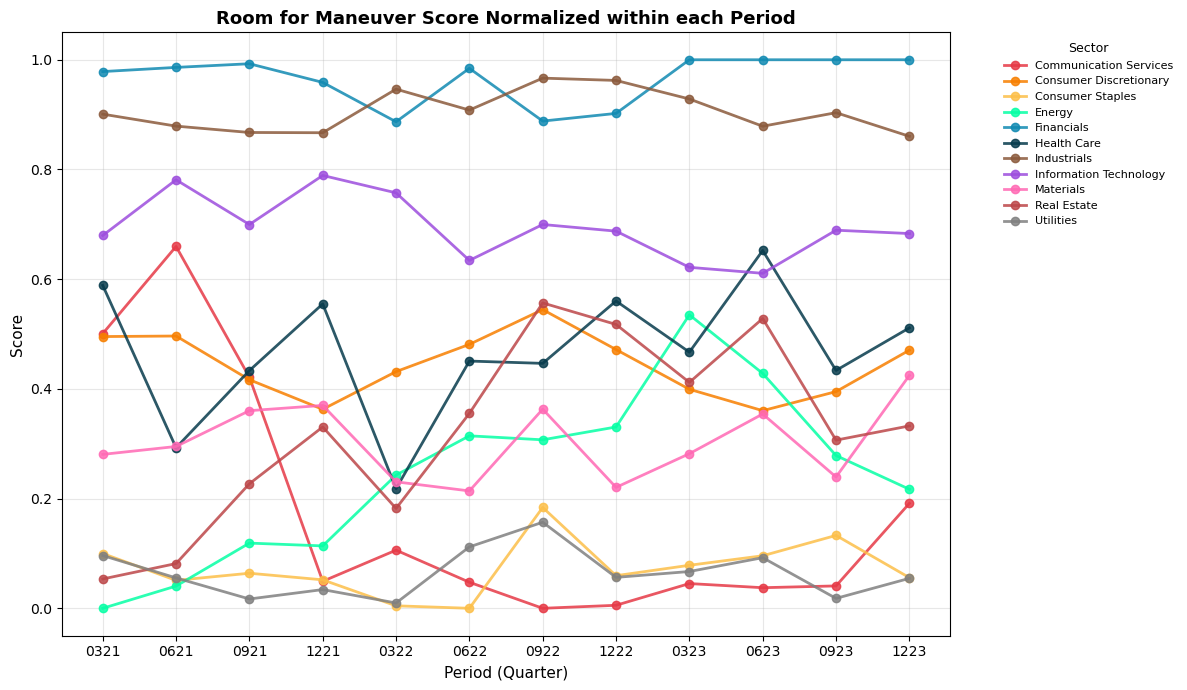

In [110]:
plot_sector_evolution(room_for_maneveur, value_col="Room_for_Maneuver_Score_within_period", title="Room for Maneuver Score Normalized within each Period", ylabel = 'Score', figsize=(12,7), show=False)

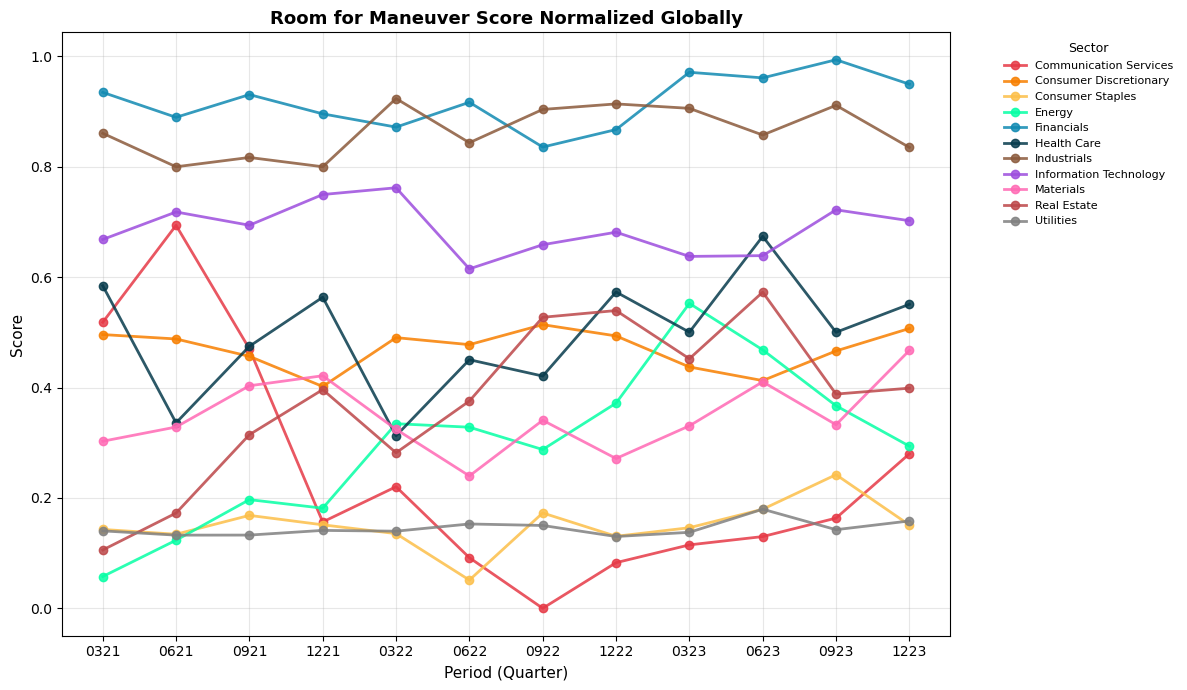

In [111]:
plot_sector_evolution(room_for_maneveur, value_col="Room_for_Maneuver_Score_global", title="Room for Maneuver Score Normalized Globally", ylabel = 'Score', figsize=(12,7), show=False)

### However if we look at Flexibility, the picture changes.

In [112]:
flexibility = pd.read_excel("results/flexibility/sector_flexibility_raw.xlsx", dtype={'Period':str})

In [113]:
# Normalize each metric within each period
flexibility["Median_bandwidth_within_period"] = flexibility.groupby("Period")["Median_bandwidth"].transform(minmax_within_period)
flexibility["L2_lower_bound_same_obj_within_period"]      = flexibility.groupby("Period")["L2_lower_bound_same_obj"].transform(minmax_within_period)

# Average (already in [0,1], so no second normalization needed)
flexibility["Flexibility_Score_within_period"] = (flexibility["Median_bandwidth_within_period"] + flexibility["L2_lower_bound_same_obj_within_period"]) / 2

flexibility["Median_bandwidth_global"] = minmax_global(flexibility["Median_bandwidth"])
flexibility["L2_lower_bound_same_obj_global"]      = minmax_global(flexibility["L2_lower_bound_same_obj"])
flexibility["Flexibility_Score_global"] = (flexibility["Median_bandwidth_global"] + flexibility["L2_lower_bound_same_obj_global"]) / 2

### For the Flexibility dimension, the resulting score changes more noticeably depending on the normalization approach. This is mainly because the median bandwidth metric shows a much larger spread in its values Globally than the L2 metric.

### Under global normalization, the wider range of the median bandwidth metric means that it tends to drive most of the variation in the overall flexibility score when the two metrics are averaged, even though both metrics are assigned equal weights.

### Under within-period normalization, each metric is scaled relative to the cross-sector spread observed in that specific period. This helps ensure that both metrics contribute more evenly to the final flexibility score.

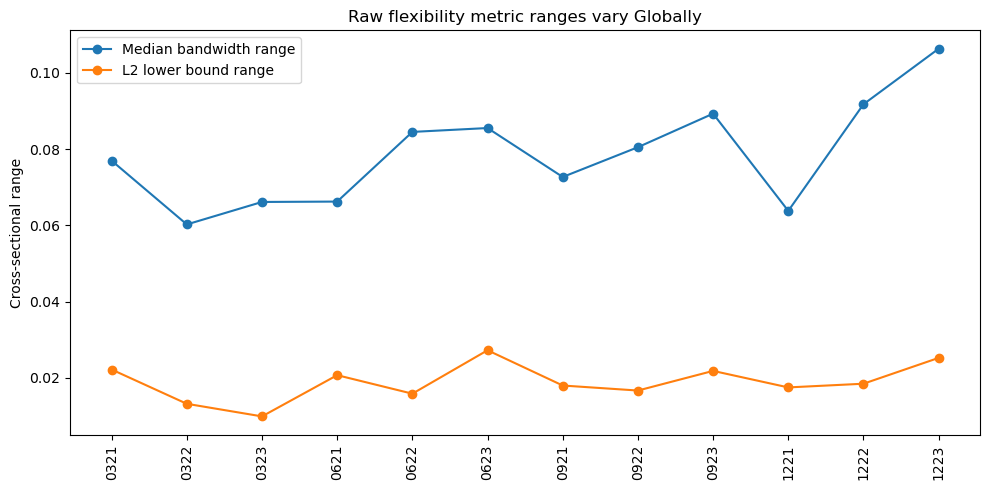

In [114]:
import matplotlib.pyplot as plt

metric_ranges = (
    flexibility.groupby("Period")
    .agg(
        bw_range=("Median_bandwidth", lambda x: x.max() - x.min()),
        l2_range=("L2_lower_bound_same_obj", lambda x: x.max() - x.min())
    )
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(metric_ranges["Period"], metric_ranges["bw_range"], marker="o", label="Median bandwidth range")
plt.plot(metric_ranges["Period"], metric_ranges["l2_range"], marker="o", label="L2 lower bound range")
plt.xticks(rotation=90)
plt.ylabel("Cross-sectional range")
plt.title("Raw flexibility metric ranges vary Globally")
plt.legend()
plt.tight_layout()
plt.show()

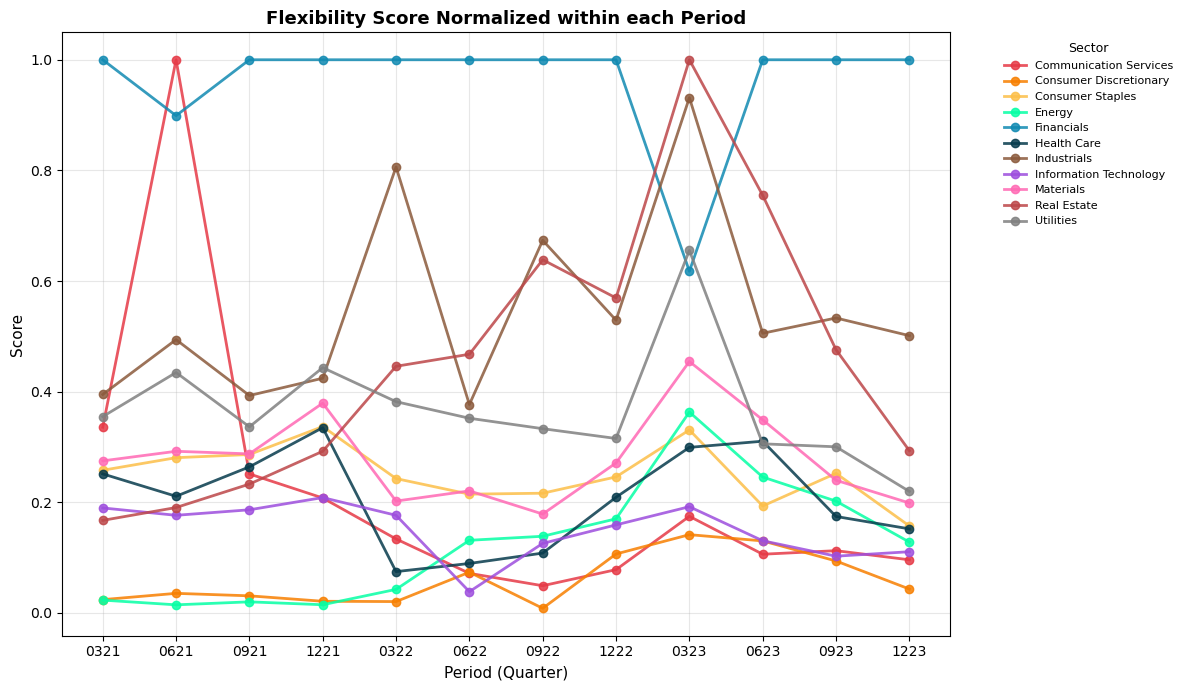

In [115]:
plot_sector_evolution(flexibility, value_col="Flexibility_Score_within_period", title="Flexibility Score Normalized within each Period", ylabel = 'Score', figsize=(12,7), show=False)

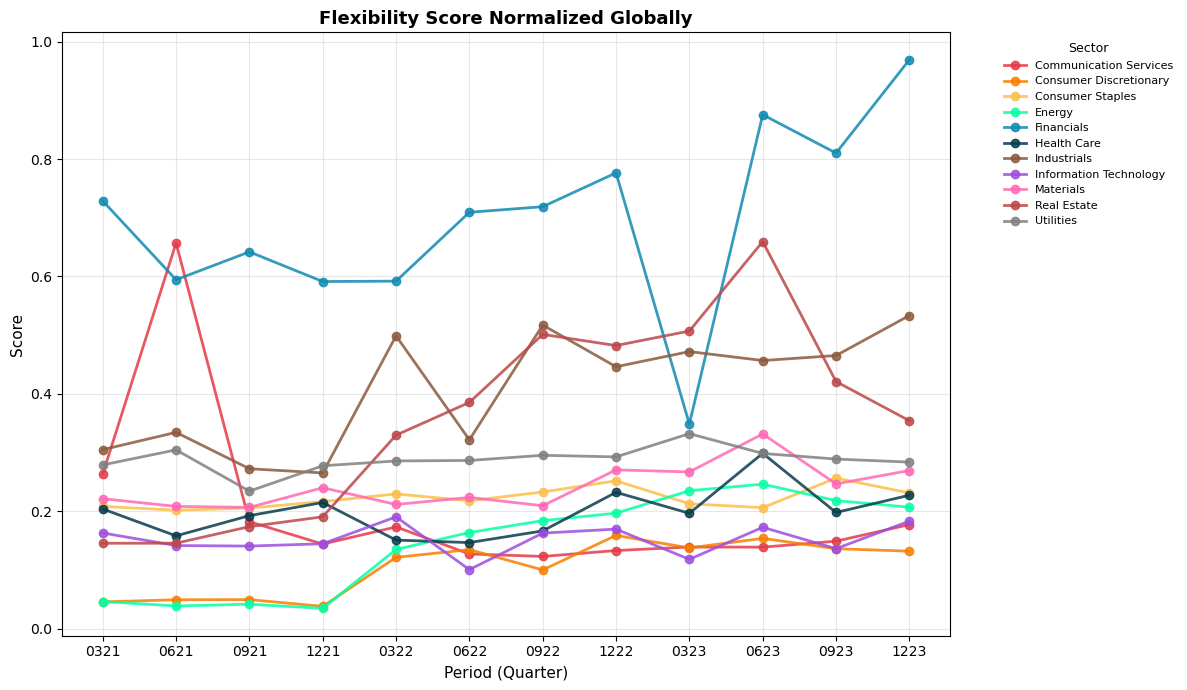

In [116]:
plot_sector_evolution(flexibility, value_col="Flexibility_Score_global", title="Flexibility Score Normalized Globally", ylabel = 'Score', figsize=(12,7), show=False)

In [117]:
sensitivity = pd.read_excel("results/sensitivity/sensitivity_scores_by_period.xlsx", dtype={'Period':str})
# Higher turnover => less stable => higher instability
sensitivity["Turnover_within_period"] = sensitivity.groupby("Period")["Median_Turnover_pct"].transform(minmax_within_period) 

sensitivity["Cosine_within_period"]   = sensitivity.groupby("Period")["Inv_Median_Cosine"].transform(minmax_within_period)  

# Larger carbon loss => more sensitive => higher instability
sensitivity["CarbonLoss_within_period"] =sensitivity.groupby("Period")["P95_CarbonLoss_pp"].transform(minmax_within_period) 

# Equal-weight composite instability score (each component contributes 1/3)
sensitivity["Sensitivity_Score_within_period"] = 1- (1/3 * (sensitivity["Turnover_within_period"] + sensitivity["Cosine_within_period"] + sensitivity["CarbonLoss_within_period"]))

# Higher turnover => less stable => higher instability
sensitivity["Turnover_global"] = minmax_global(sensitivity["Median_Turnover_pct"])

sensitivity["Cosine_global"]   = minmax_global(sensitivity["Inv_Median_Cosine"])
sensitivity
# Larger carbon loss => more sensitive => higher instability
sensitivity["CarbonLoss_global"] = minmax_global(sensitivity["P95_CarbonLoss_pp"])

# Equal-weight composite instability score (each component contributes 1/3)
sensitivity["Sensitivity_Score_global"] = 1- (1/3 * (sensitivity["Turnover_global"] + sensitivity["Cosine_global"] + sensitivity["CarbonLoss_global"]))

### An outlier like  obstervation in a metric in a period can dominate in the final dimension score, while for within-period normalization the comparison is between each period. This is the case for  Financials will in 0922 that will ddominate the final sensitivity score (that is inversed) for global normalization but not for within period normalization.

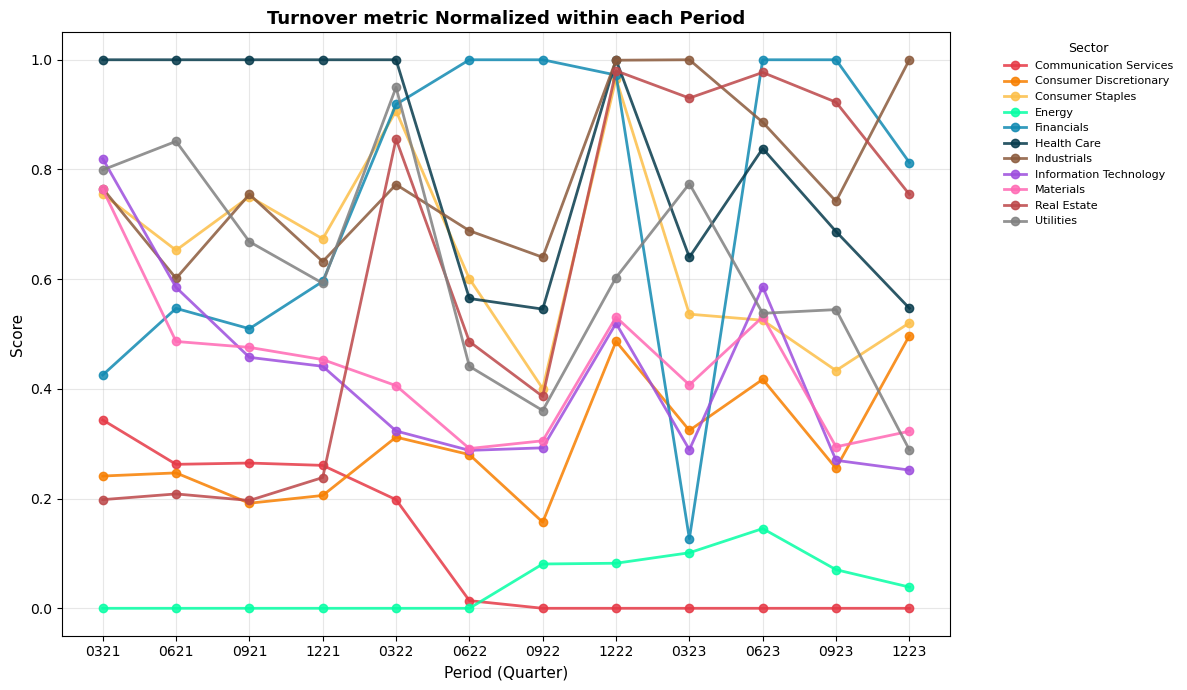

In [118]:
plot_sector_evolution(sensitivity, value_col="Turnover_within_period", title="Turnover metric Normalized within each Period", ylabel = 'Score', figsize=(12,7), show=False)

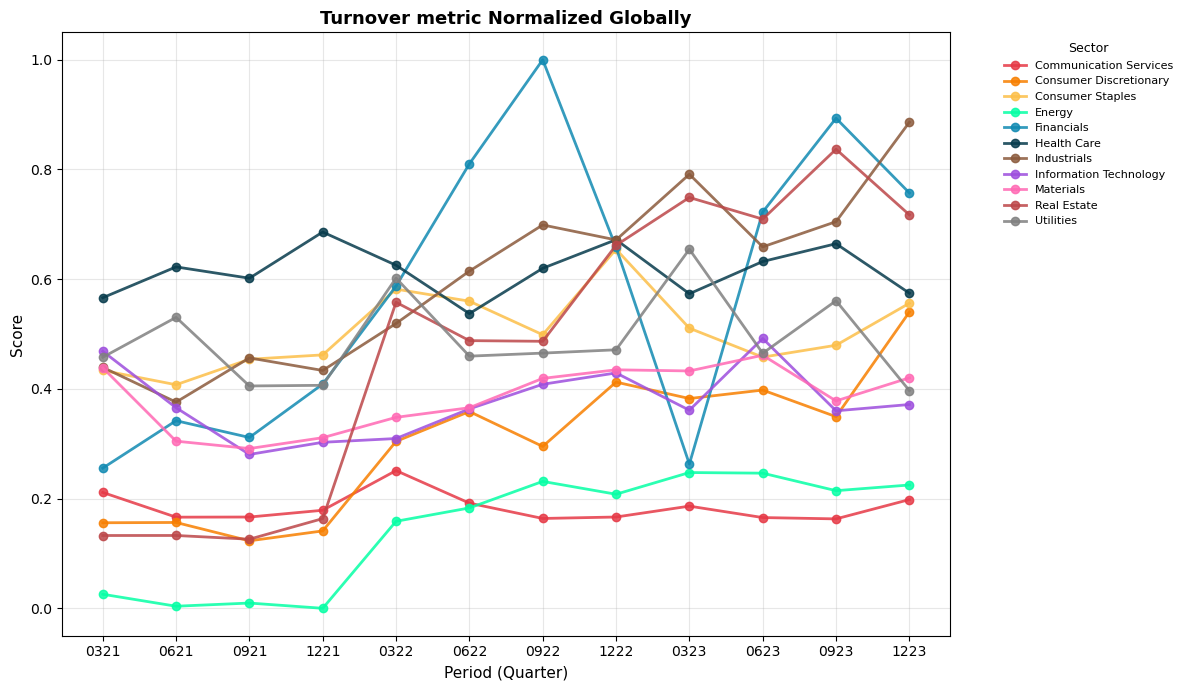

In [119]:
plot_sector_evolution(sensitivity, value_col="Turnover_global", title="Turnover metric Normalized Globally", ylabel = 'Score', figsize=(12,7), show=False)

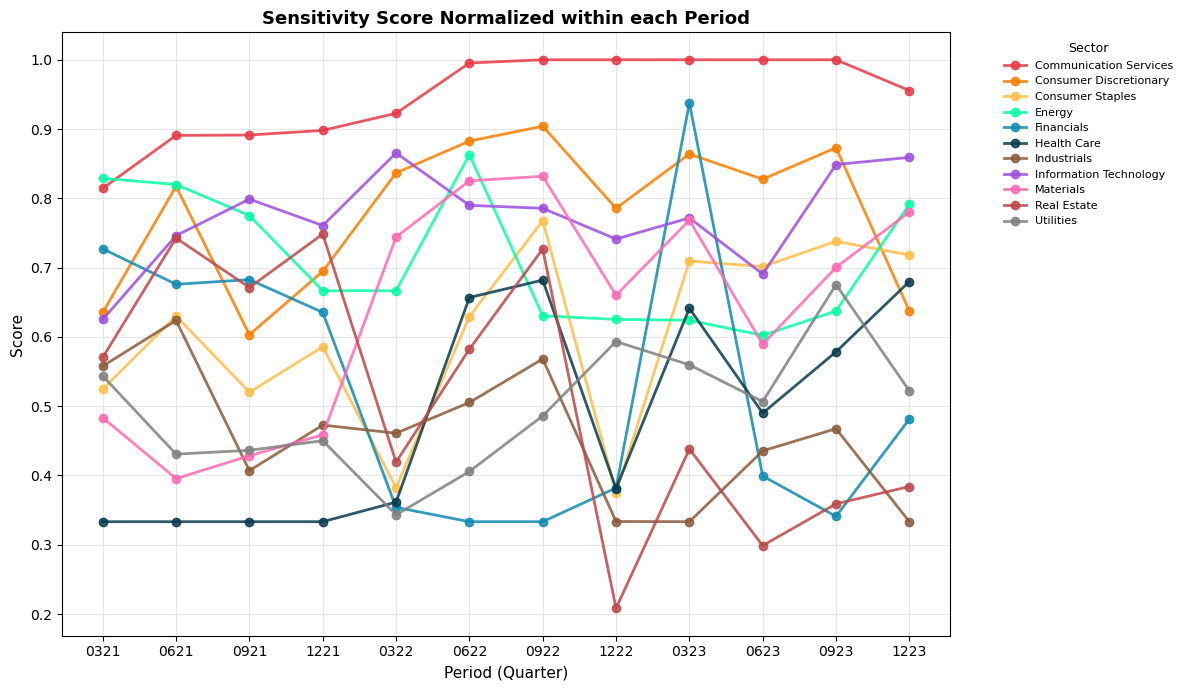

In [120]:
plot_sector_evolution(sensitivity, value_col="Sensitivity_Score_within_period", title="Sensitivity Score Normalized within each Period", ylabel = 'Score', figsize=(12,7), show=False)

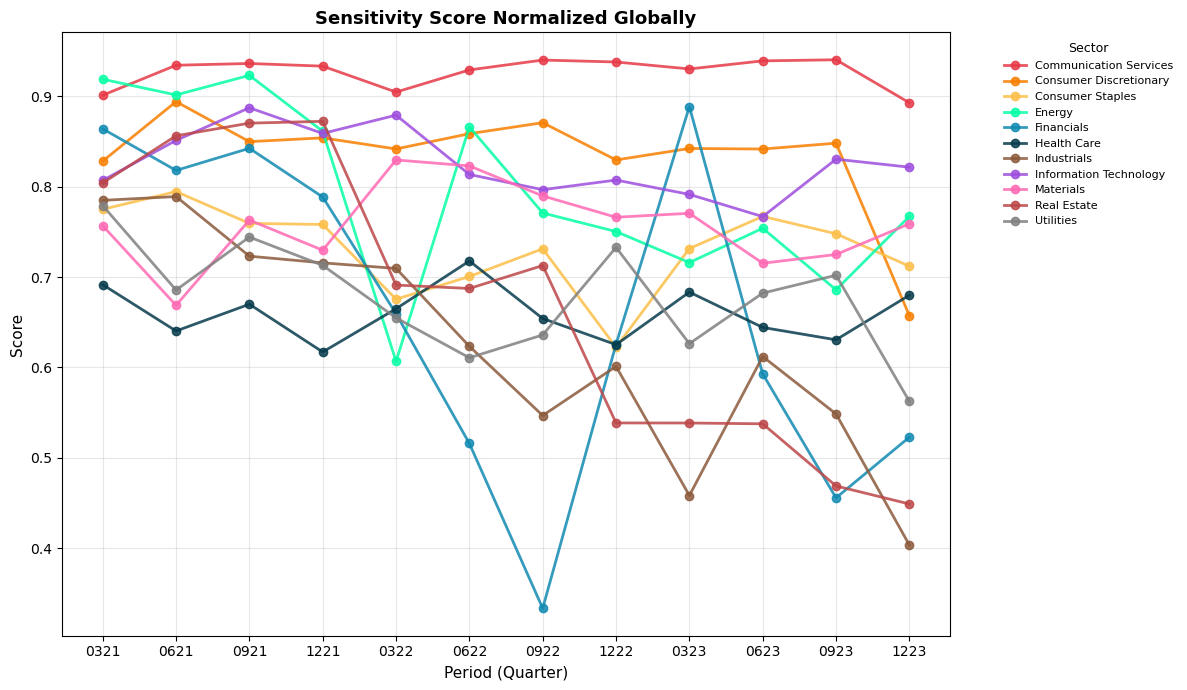

In [121]:
plot_sector_evolution(sensitivity, value_col="Sensitivity_Score_global", title="Sensitivity Score Normalized Globally", ylabel = 'Score', figsize=(12,7), show=False)

In [122]:
robustness = pd.read_excel("results/robustness/robustness_scores_by_period.xlsx", dtype={'period':str})
robustness['Sector'] = robustness['sector'] 
robustness['Period'] = robustness['period'] 
robustness['Robustness_Score_within_period'] = 1 - robustness.groupby("Period")["Robustness_Ratio"].transform(minmax_within_period)
robustness['Robustness_Score_global'] = 1 - minmax_global(robustness["Robustness_Ratio"])

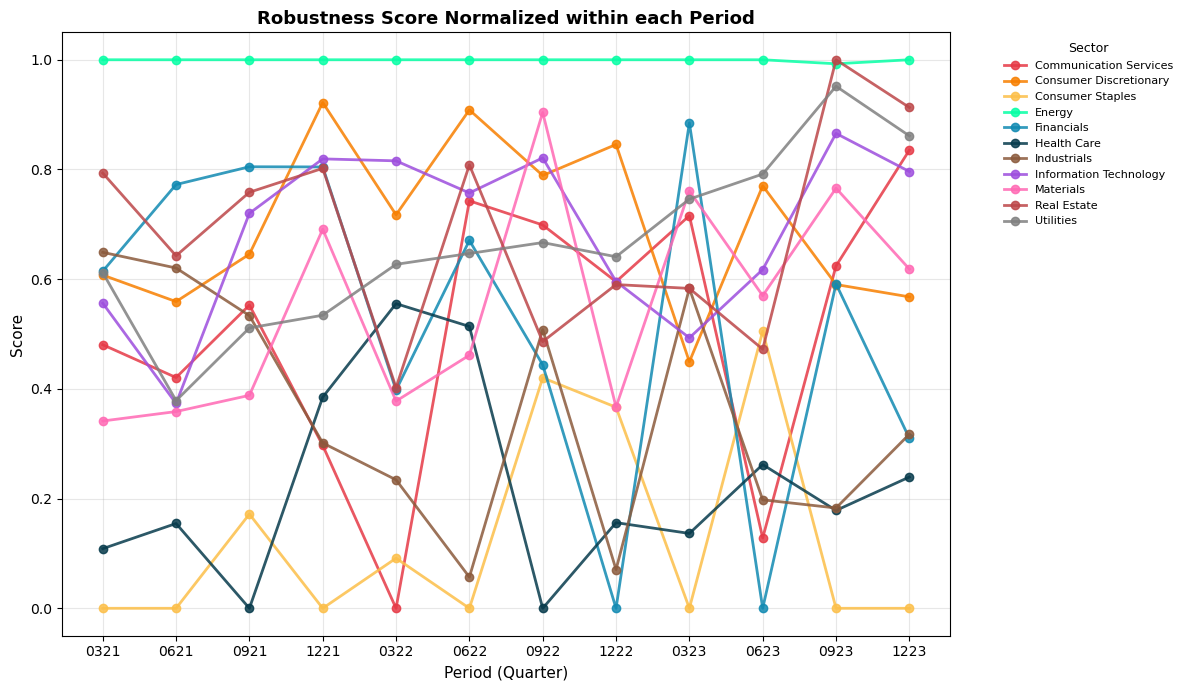

In [123]:
plot_sector_evolution(robustness, value_col="Robustness_Score_within_period", title="Robustness Score Normalized within each Period", ylabel = 'Score', figsize=(12,7), show=False)

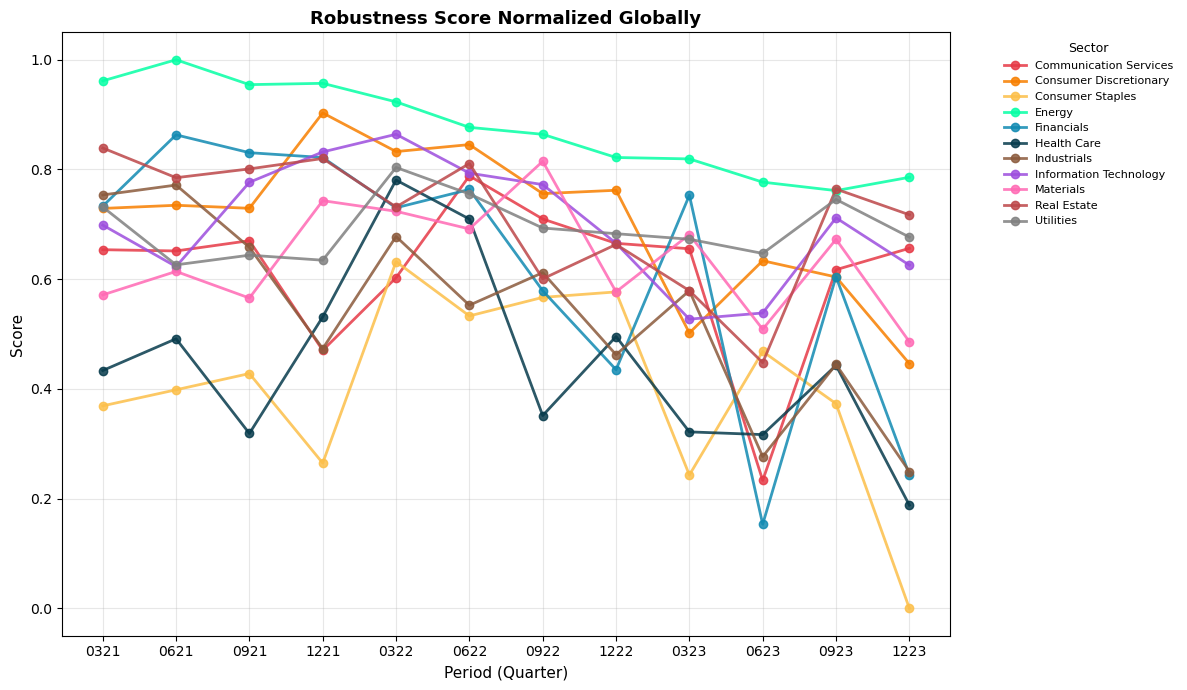

In [124]:
plot_sector_evolution(robustness, value_col="Robustness_Score_global", title="Robustness Score Normalized Globally", ylabel = 'Score', figsize=(12,7), show=False)

In [125]:
robustness.groupby('Sector')['Robustness_Score_within_period'].mean().sort_values()

Sector
Consumer Staples          0.129584
Health Care               0.224155
Industrials               0.354614
Communication Services    0.507607
Financials                0.524585
Materials                 0.550356
Utilities                 0.664006
Information Technology    0.685952
Real Estate               0.687678
Consumer Discretionary    0.697702
Energy                    0.999390
Name: Robustness_Score_within_period, dtype: float64

In [126]:
robustness.groupby('Sector')['Robustness_Score_global'].mean().sort_values()

Sector
Consumer Staples          0.404406
Health Care               0.448417
Industrials               0.542556
Communication Services    0.614489
Financials                0.625869
Materials                 0.637503
Utilities                 0.692770
Information Technology    0.702366
Consumer Discretionary    0.706475
Real Estate               0.713351
Energy                    0.875208
Name: Robustness_Score_global, dtype: float64